NOTEBOOK för att testa SOM modell på ett känt dataset 

med egna SOM-klassen

Dataset IRIS from SKLEARN 
4 features och 3 arter

In [1]:
import os
import sys

print(f"Notebooken körs från: {os.getcwd()}")
print(f"Mappar som Python letar i: {sys.path[:3]}")

Notebooken körs från: c:\Users\pat19\OneDrive\Skrivbord\Thesis\CLAS_SOM_project\notebooks
Mappar som Python letar i: ['C:\\Users\\pat19\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip', 'C:\\Users\\pat19\\AppData\\Local\\Programs\\Python\\Python311\\DLLs', 'C:\\Users\\pat19\\AppData\\Local\\Programs\\Python\\Python311\\Lib']


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# din klass
from som_model import GeneralCLASSOM

In [3]:
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print(X.shape)
print(class_names)

(150, 4)
['setosa' 'versicolor' 'virginica']


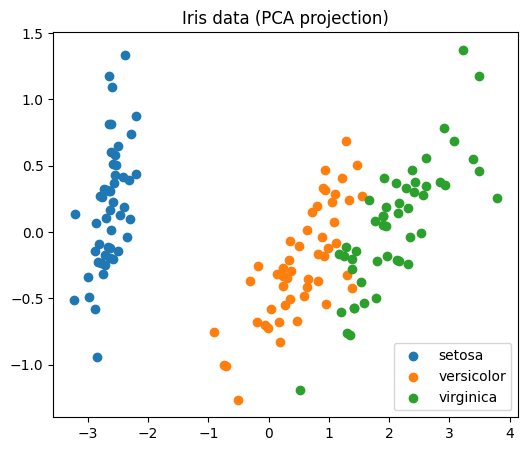

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))

for i, name in enumerate(class_names):
    plt.scatter(
        X_pca[y==i,0],
        X_pca[y==i,1],
        label=name
    )

plt.legend()
plt.title("Iris data (PCA projection)")
plt.show()

In [5]:
som_model_iris = GeneralCLASSOM(
    x=15,
    y=15,
    input_len=4,
    sigma=1.5,
    learning_rate=0.5
)

som_model_iris.get_summary()

{'x': 15,
 'y': 15,
 'input_len': 4,
 'sigma': 1.5,
 'learning_rate': 0.5,
 'decay_function': 'asymptotic_decay',
 'neighborhood_function': 'gaussian',
 'topology': 'rectangular',
 'activation_distance': 'euclidean',
 'sigma_decay_function': 'asymptotic_decay',
 'random_seed': 42}

In [6]:
som_model_iris.train(
    X,
    iterations=5000,
    mode="batch",
    use_pca=True
)

 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.0711154994874687
Training completed (5000 iterations)


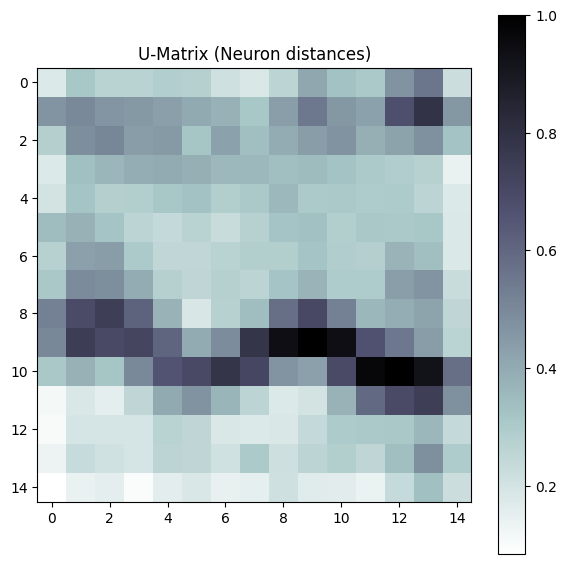

In [7]:
u_matrix = som_model_iris.get_u_matrix()

plt.figure(figsize=(7,7))
plt.imshow(u_matrix, cmap="bone_r")
plt.colorbar()
plt.title("U-Matrix (Neuron distances)")
plt.show()

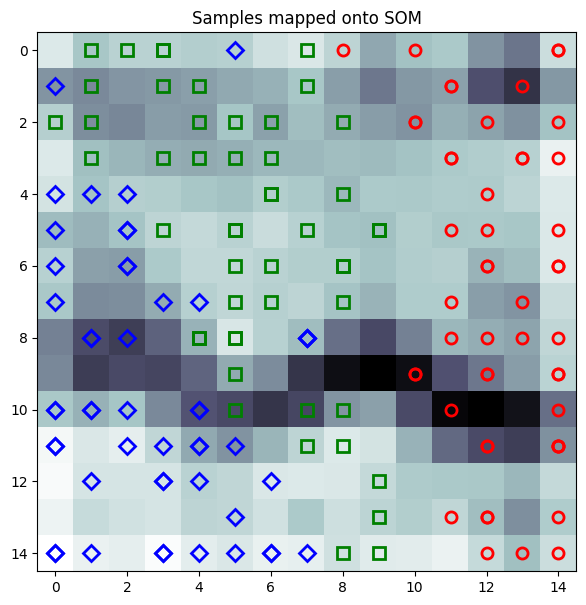

In [8]:
plt.figure(figsize=(7,7))
plt.imshow(u_matrix, cmap="bone_r")

markers = ['o','s','D']
colors = ['r','g','b']

for i, x in enumerate(X):
    w = som_model_iris.som.winner(
        som_model_iris.scaler.transform([x])[0]
    )

    plt.plot(
        w[0],
        w[1],
        markers[y[i]],
        markerfacecolor='None',
        markeredgecolor=colors[y[i]],
        markersize=8,
        markeredgewidth=2
    )

plt.title("Samples mapped onto SOM")
plt.show()

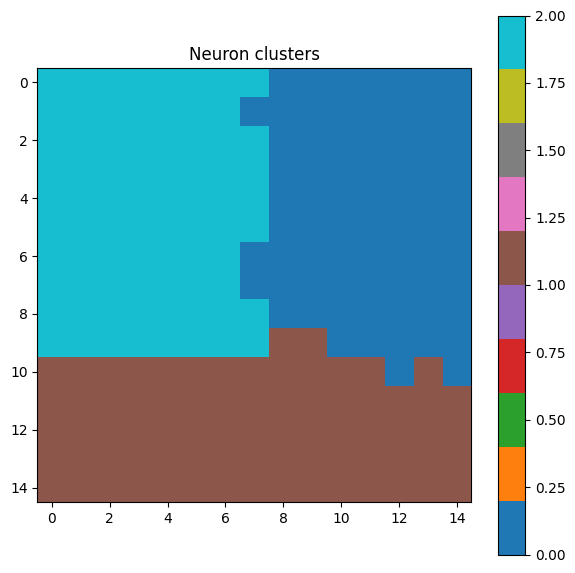

In [9]:
clusters = som_model_iris.create_clusters(
    data=X,
    n_clusters=3,
    method="neurons"
)

plt.figure(figsize=(7,7))
plt.imshow(clusters, cmap="tab10")
plt.colorbar()
plt.title("Neuron clusters")
plt.show()

In [10]:
pred = som_model_iris.predict_cluster(X)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, pred))

[[ 0 49  1]
 [15  0 35]
 [36  0 14]]


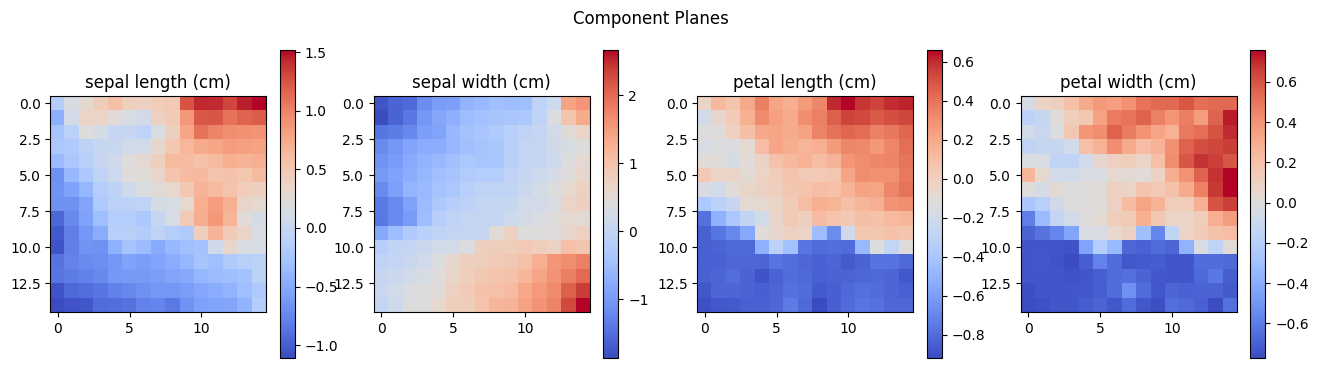

In [11]:
weights = som_model_iris.som.get_weights()

n_features = weights.shape[2]

fig, axes = plt.subplots(1, n_features, figsize=(16,4))

for i in range(n_features):
    ax = axes[i]
    im = ax.imshow(weights[:,:,i], cmap="coolwarm")
    ax.set_title(feature_names[i])
    plt.colorbar(im, ax=ax)

plt.suptitle("Component Planes")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_som_mapping(model, data, labels):

    scaled = model.scaler.transform(data)

    plt.figure(figsize=(8,8))

    colors = ['red','green','blue']
    markers = ['o','s','^']

    for i, x in enumerate(scaled):

        winner = model.som.winner(x)

        # jitter så punkter inte ligger exakt ovanpå varandra
        jitter_x = winner[0] + np.random.uniform(-0.3,0.3)
        jitter_y = winner[1] + np.random.uniform(-0.3,0.3)

        plt.scatter(
            jitter_x,
            jitter_y,
            c=colors[labels[i]],
            marker=markers[labels[i]],
            edgecolors='black',
            s=80
        )

    plt.xlim(-0.5, model.x-0.5)
    plt.ylim(-0.5, model.y-0.5)

    plt.grid(True)
    plt.title("Iris datapoints mapped to SOM neurons")

    plt.show()

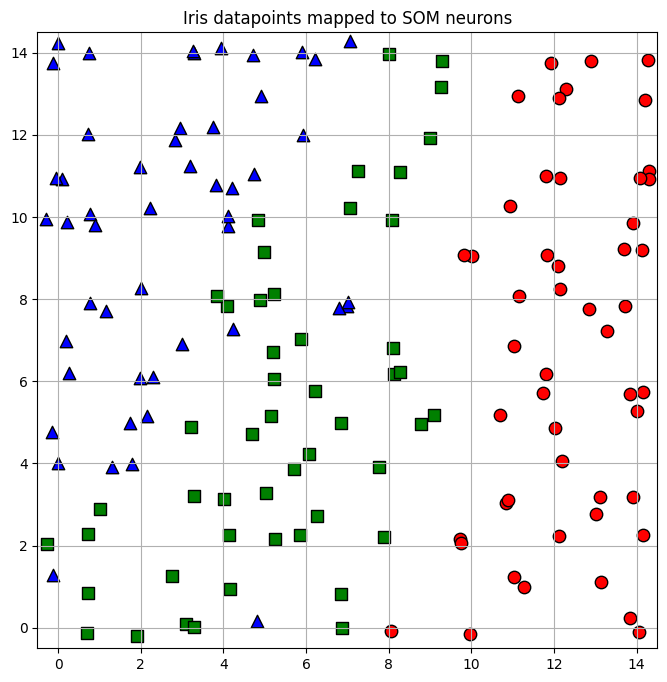

In [21]:
plot_som_mapping(som_model_iris, X, y)

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_raw_som_mapping(model, data):

    scaled = model.scaler.transform(data)

    plt.figure(figsize=(8,8))

    for x in scaled:

        winner = model.som.winner(x)

        # jitter så punkter inte ligger exakt ovanpå varandra
        jitter_x = winner[0] + np.random.uniform(-0.35,0.35)
        jitter_y = winner[1] + np.random.uniform(-0.35,0.35)

        plt.scatter(
            jitter_x,
            jitter_y,
            c="black",
            s=50,
            alpha=0.7
        )

    plt.xlim(-0.5, model.x-0.5)
    plt.ylim(-0.5, model.y-0.5)

    plt.grid(True)
    plt.title("Raw SOM mapping of datapoints")

    plt.show()

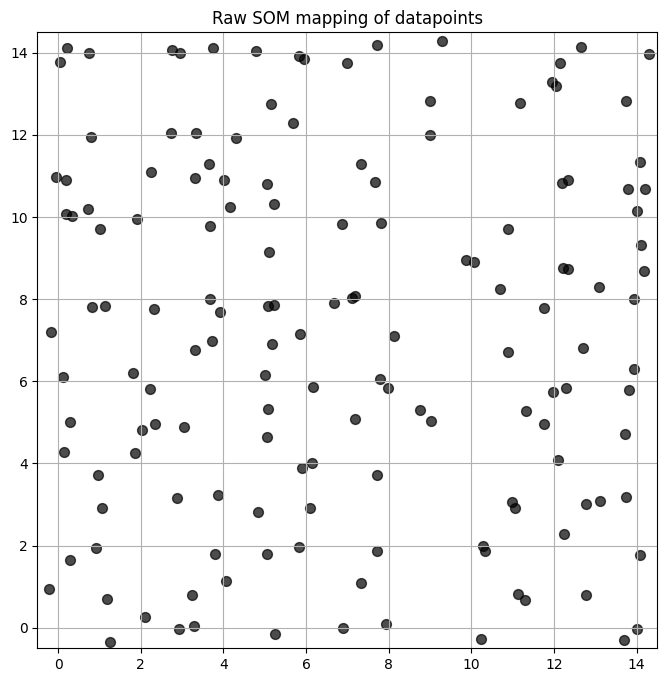

In [23]:
plot_raw_som_mapping(som_model_iris, X)

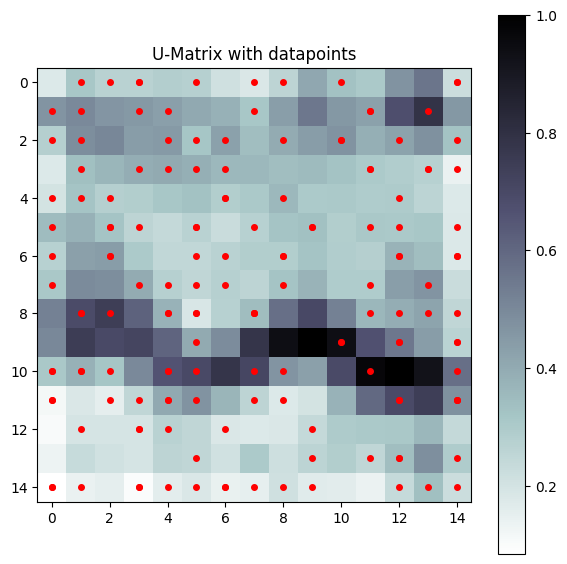

In [25]:
u = som_model_iris.som.distance_map()

plt.figure(figsize=(7,7))
plt.imshow(u, cmap="bone_r")
plt.colorbar()

scaled = som_model_iris.scaler.transform(X)

for x in scaled:
    w = som_model_iris.som.winner(x)
    plt.plot(w[0], w[1], "ro", markersize=4)

plt.title("U-Matrix with datapoints")
plt.show()

1. U-matrix = karta över avstånd
2. hitta mörka områden (klustergränser)
3. dela upp ljusa regioner
4. varje region = ett kluster

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi

# invert eftersom watershed hittar minima
distance = 1 - u

# hitta lokala minima (klustercentra)
coords = peak_local_max(distance, footprint=np.ones((3,3)), labels=None)

mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True

markers, _ = ndi.label(mask)

# watershed segmentation
labels = watershed(-distance, markers, mask=np.ones_like(distance))

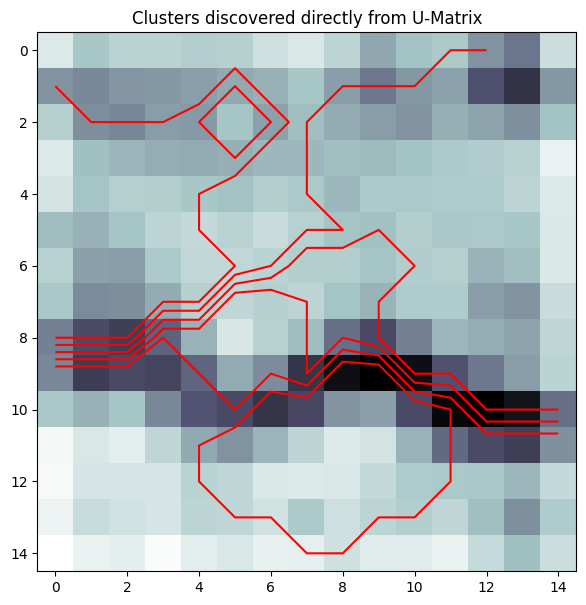

In [27]:
plt.figure(figsize=(7,7))

plt.imshow(u, cmap="bone_r")
plt.contour(labels, colors="red")

plt.title("Clusters discovered directly from U-Matrix")
plt.show()

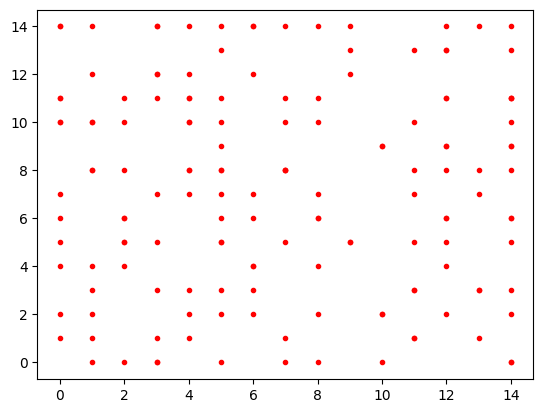

In [28]:
scaled = som_model_iris.scaler.transform(X)

for x in scaled:
    w = som_model_iris.som.winner(x)
    plt.plot(w[0], w[1], "ro", markersize=3)
    